In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

from ipywidgets import interact, FloatSlider


V min/max: 0.0 1.0
Mean electric field: -1.0
Mean current density: -0.5


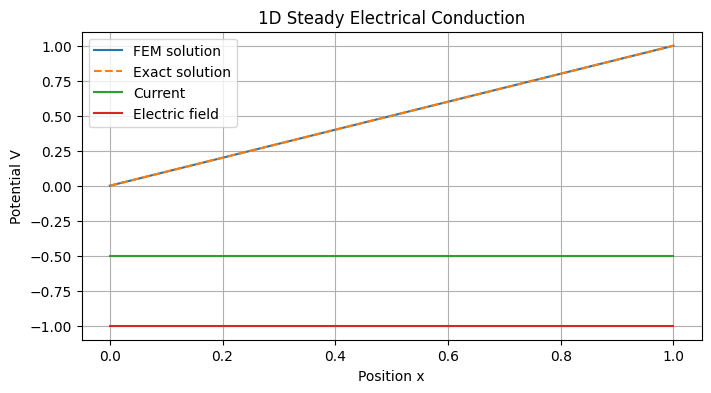

In [35]:

def FEM_element_based(sigma_values, L, Nx):
    h = L / (Nx - 1)

    K_global = np.zeros((Nx, Nx))

    for e in range(Nx - 1):
        sigma = sigma_values[e]
        K_e = (sigma / h) * np.array([[1, -1], [-1, 1]])
        K_global[e:e+2, e:e+2] += K_e

    return K_global, h


def BC_Solver(K_Full, L_BC, R_BC):

    Nx = K_Full.shape[0]
    # Potential
    V = np.zeros(Nx)
    V[0] =  L_BC
    V[-1] = R_BC

    # Reduced matrix
    K = csr_matrix(K_Full[1:-1, 1:-1])

    # RHS: no source in the PDE, but boundary values contribute
    b = np.zeros(Nx - 2)
    b[0]  -= K_Full[1,0]   * V[0]
    b[-1] -= K_Full[-2,-1] * V[-1]

    # Solve
    V_interior = spsolve(K, b)
    V[1:-1] = V_interior
    return V


# Parameters
L = 1.0
Nx = 50
x = np.linspace(0, L, Nx)

sigma_values = 0.5 * np.ones(Nx) # The conductivity parameter

# Assemble full matrix
K_full, h = FEM_element_based(sigma_values, L, Nx)

# Incorporate BC, and solve
V = BC_Solver(K_full, 0.0, 1.0)

# Derived quantities
E = -np.gradient(V, x)
J = sigma_values * E

print("V min/max:", V.min(), V.max())
print("Mean electric field:", np.mean(E))
print("Mean current density:", np.mean(J))

# Exact solution
V_exact = x / L

# Plot
plt.figure(figsize=(8, 4))
plt.plot(x, V, label='FEM solution')
plt.plot(x, V_exact, '--', label='Exact solution')
plt.plot(x, J, label='Current')
plt.plot(x, E, label='Electric field')
plt.xlabel('Position x')
plt.ylabel('Potential V')
plt.title('1D Steady Electrical Conduction')
plt.grid(True)
plt.legend()
#plt.savefig("./FEM/P1d.png", dpi=200)
plt.show()

The next goal is to make $\sigma$ dynamic, but we start with a simple artificial process of making it variable of some constant, let $x$

$$=> \sigma(x) = x^2$$

**Remark**: The properties should be assigned to elements, because nodes are the soutions, so:
$$x_i = \frac {x_{i-1} + x_{i+1}}{2}$$

# 1D Electrical Conduction with Variable Conductivity

We consider steady-state 1D electrical conduction with spatially varying conductivity:

$$
\frac{d}{dx} \left( \sigma(x)\frac{dV}{dx} \right) = 0
$$

with Dirichlet boundary conditions:

$$
V(0)=0, \quad V(L)=1
$$

Instead of a constant material property, we define:

$$
\sigma(x) = 1 + x^2
$$
  

In [36]:
# First we define a function
def sigma_x(x):
    return 1 + x**2

# Now we fill up the sigma 

x_node = np.linspace(0, L, Nx)
x_elem = 0.5 * x_node[:-1] + x_node[1:]

sigma_vals = sigma_x(x_elem)

# Assemble full matrix
K_full, h = FEM_element_based(sigma_vals, L, Nx)


# Incorporate BC, and solve
V = BC_Solver(K_full, 0.0, 1.0)


# Derived quantities
# element wise electric field
E = -(V[1:] - V[:-1])/h
#E = -np.gradient(V, x)
J = sigma_vals * E


print("V min/max:", V.min(), V.max())
print("Mean electric field:", np.mean(E))
print("Mean current density:", np.mean(J))


# Exact solution
V_exact = x / L



V min/max: 0.0 1.0
Mean electric field: -1.0000000000000002
Mean current density: -1.5317555586831506


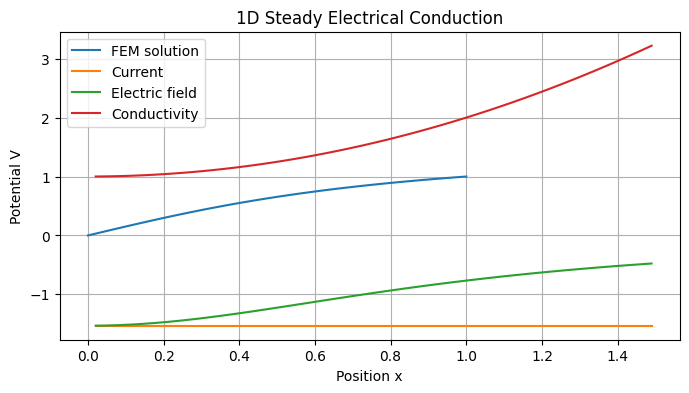

In [37]:
# Plot
plt.figure(figsize=(8, 4))
plt.plot(x_node, V, label='FEM solution')
#plt.plot(x, V_exact, '--', label='Exact solution')
plt.plot(x_elem, J, label='Current')
plt.plot(x_elem, E, label='Electric field')
plt.plot(x_elem,sigma_vals, label='Conductivity')
plt.xlabel('Position x')
plt.ylabel('Potential V')
plt.title('1D Steady Electrical Conduction')
plt.grid(True)
plt.legend()
#plt.savefig("./FEM/P1d.png", dpi=200)
plt.show()

Perhaps a normalization would help to analyze better.

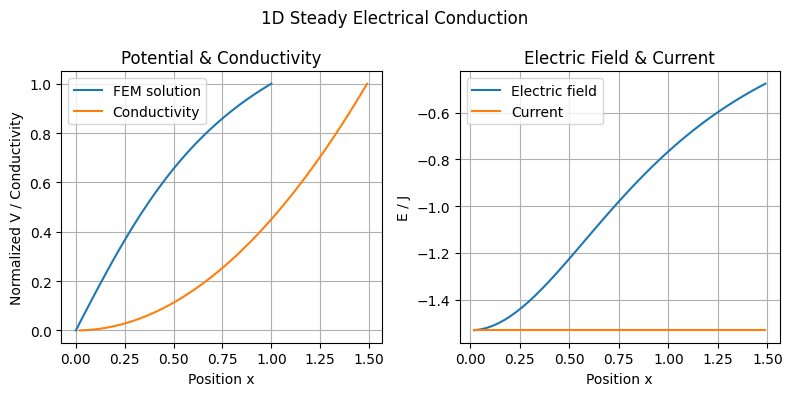

In [38]:
sigma_norm = (sigma_vals - sigma_vals.min()) / (sigma_vals.max() - sigma_vals.min())
V_norm = (V - V.min()) / (V.max() - V.min())
# E_norm = (E - E.min()) / (E.max() - E.min())
# J_norm = (J - J.min()) / (J.max() - J.min())
# print(sigma_norm)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(8, 4))  # CORRECTED: use subplots()

axs[0].plot(x_node, V_norm, label='FEM solution')
axs[0].plot(x_elem, sigma_norm, label='Conductivity')
# axs[0].plot(x, V_exact, '--', label='Exact solution')

axs[1].plot(x_elem, E, label='Electric field')
axs[1].plot(x_elem, J, label='Current')

# Labels and titles
axs[0].set_xlabel('Position x')
axs[0].set_ylabel('Normalized V / Conductivity')
axs[0].set_title('Potential & Conductivity')
axs[0].grid(True)
axs[0].legend()

axs[1].set_xlabel('Position x')
axs[1].set_ylabel('E / J')
axs[1].set_title('Electric Field & Current')
axs[1].grid(True)
axs[1].legend()

fig.suptitle('1D Steady Electrical Conduction')
fig.tight_layout()  # Prevents overlap
# plt.savefig("./FEM/P1d.png", dpi=200)
plt.show()  # CORRECTED: use plt.show() instead of fig.show()

In [39]:
print("J variation:", J.max() - J.min())

J variation: 9.725553695716371e-14


In modeling electromechanical transport, it is important to distinguish between **geometric effects** and **material effects**. Geometric changes arise from deformation of the domain (e.g., changes in length $L$ or area $A$), which influence quantities like resistance through relations such as $R = \frac{L}{A\sigma}$. In contrast, material effects describe how intrinsic properties, such as the electrical conductivity $\sigma$, change due to deformation. In semiconductors, this latter effect—known as **piezoresistivity**—is often dominant.

To describe this, conductivity is treated as a function of strain:
$$
\sigma = \sigma(\varepsilon)
$$
where $\varepsilon$ represents the mechanical strain. The exact functional dependence is generally unknown or too complex to derive directly from microscopic physics. However, for small deformations, it is reasonable to assume that $\sigma(\varepsilon)$ is smooth and can be approximated locally using a Taylor expansion:
$$
\sigma(\varepsilon) \approx \sigma_0 + \frac{d\sigma}{d\varepsilon}\varepsilon + \frac{1}{2}\frac{d^2\sigma}{d\varepsilon^2}\varepsilon^2 + \dots
$$

Factoring out the reference conductivity $\sigma_0$ yields:
$$
\sigma(\varepsilon) = \sigma_0 \left( 1 + \pi \varepsilon + \alpha \varepsilon^2 + \dots \right)
$$
where $\pi$ is the **linear piezoresistive coefficient** and $\alpha$ captures higher-order nonlinear effects. This expansion is not geometric in nature; rather, it approximates how the **internal electronic transport properties** respond to deformation.

Physically, strain modifies the crystal lattice, which in turn alters band structure, carrier mobility, and scattering mechanisms. These changes affect quantities such as the relaxation time $\tau$, and since conductivity is related to transport properties (e.g., $\sigma \sim \tau$), it becomes strain-dependent. Thus, the Taylor expansion provides a systematic way to capture this coupling between mechanics and transport without requiring a full microscopic derivation.

In [40]:
# Strain model
# Later replace this with FEM strain
def strain_field(x_elem, eps0):
    return eps0 * np.sin(np.pi * x_elem)

# Conductivity model
# sigma(eps) = sigma0(1 + pi eps + alpha eps^2)
def sigma_from_strain(eps_elem, sigma0, pi_coeff, alpha):
    return sigma0 * (1 + pi_coeff * eps_elem + alpha * eps_elem**2)

import os
from datetime import datetime

OUT_DIR = "../paper/Images"
os.makedirs(OUT_DIR, exist_ok=True)

def run_model(sigma0=0.5, pi_coeff=10.0, alpha=0.0, eps0=0.01, save=False):
    L = 1.0
    Nx = 100

    x_node = np.linspace(0, L, Nx)
    x_elem = 0.5 * (x_node[:-1] + x_node[1:])

    eps_elem = strain_field(x_elem, eps0)
    sigma_elem = sigma_from_strain(eps_elem, sigma0, pi_coeff, alpha)

    if np.any(sigma_elem <= 0):
        print(f"Unphysical: sigma_min = {sigma_elem.min():.3e}")
        return

    K_full, h = FEM_element_based(sigma_elem, L, Nx)
    V = BC_Solver(K_full, 0.0, 1.0)

    E_elem = -(V[1:] - V[:-1]) / h
    J_elem = sigma_elem * E_elem

    # ---- Diagnostics ----
    diagnostics = {
        "sigma_min": sigma_elem.min(),
        "sigma_max": sigma_elem.max(),
        "V_min":     V.min(),
        "V_max":     V.max(),
        "E_mean":    E_elem.mean(),
        "J_mean":    J_elem.mean(),
        "J_var":     J_elem.max() - J_elem.min(),
    }
    for k, v in diagnostics.items():
        print(f"{k:>10s}: {v:+.6e}")

    # ---- Plot ----
    fig, axs = plt.subplots(1, 3, figsize=(13, 5))

    axs[0].plot(x_elem, eps_elem, label=r"Strain $\varepsilon(x)$")
    axs[0].plot(x_elem, sigma_elem, label=r"Conductivity $\sigma(\varepsilon)$")
    axs[0].set(xlabel="Position x", ylabel="Value",
               title="Strain-Dependent Conductivity")
    axs[0].grid(True); axs[0].legend()

    axs[1].plot(x_node, V, label="Potential V")
    axs[1].set(xlabel="Position x", ylabel="Potential V",
               title="Voltage Solution")
    axs[1].grid(True); axs[1].legend()

    axs[2].plot(x_elem, E_elem, label="Electric field E")
    axs[2].plot(x_elem, J_elem, label="Current density J")
    axs[2].set(xlabel="Position x", ylabel="Value",
               title="Electric Field and Current Density")
    axs[2].grid(True); axs[2].legend()

    # Parameter banner as figure title
    param_str = (rf"$\sigma_0={sigma0:g}$, "
                 rf"$\pi={pi_coeff:g}$, "
                 rf"$\alpha={alpha:g}$, "
                 rf"$\varepsilon_0={eps0:g}$")
    fig.suptitle(f"Parametric run  |  {param_str}", fontsize=12)

    # Diagnostics footer
    footer = (f"J variation = {diagnostics['J_var']:.2e}   "
              f"σ ∈ [{diagnostics['sigma_min']:.3f}, {diagnostics['sigma_max']:.3f}]   "
              f"⟨E⟩ = {diagnostics['E_mean']:.3f}   "
              f"⟨J⟩ = {diagnostics['J_mean']:.3f}")
    fig.text(0.5, 0.01, footer, ha="center", fontsize=9,
             family="monospace", color="dimgray")

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    if save:
        fname = (f"par_s0={sigma0:g}_pi={pi_coeff:+g}"
                 f"_a={alpha:+g}_e0={eps0:g}.png")
        # Replace characters that are awkward on some filesystems
        fname = fname.replace("+", "p").replace("-", "m")
        path = os.path.join(OUT_DIR, fname)
        fig.savefig(path, dpi=200, bbox_inches="tight")
        print(f"saved: {path}")

    plt.show()

interact(
    run_model,
    sigma0=FloatSlider(min=0.1, max=2.0, step=0.1, value=0.5),
    pi_coeff=FloatSlider(min=-50, max=50, step=1, value=0),
    alpha=FloatSlider(min=-500, max=500, step=10, value=0),
    eps0=FloatSlider(min=0.0, max=0.1, step=0.005, value=0.01),
    save=False,   # checkbox in the widget — tick it when you want to write a file
)

interactive(children=(FloatSlider(value=0.5, description='sigma0', max=2.0, min=0.1), FloatSlider(value=0.0, d…

<function __main__.run_model(sigma0=0.5, pi_coeff=10.0, alpha=0.0, eps0=0.01, save=False)>

The parametric study of the conductivity model 
$$
\sigma(\varepsilon)=\sigma_0\left(1+\pi_{\text{coeff}}\varepsilon+\alpha\varepsilon^2\right)
$$
reveals a clear separation between uncoupled and coupled behavior. When $\pi_{\text{coeff}}=\alpha=0$, the system reduces to a constant conductivity case $\sigma=\sigma_0$, leading to a linear potential $V(x)$, constant electric field $E(x)$, and uniform current density $J(x)$. In this regime, strain exists but has no influence on conductivity, providing a consistent baseline for validation.

Introducing a nonzero $\pi_{\text{coeff}}$ activates linear piezoresistive coupling, whereby conductivity responds directly to strain. This results in a redistribution of the electric field, producing a nonlinear potential profile while preserving current conservation, i.e.,
$$
\frac{dJ}{dx}=0.
$$
The magnitude and sign of $\pi_{\text{coeff}}$ control the sensitivity and direction of this response, determining whether conductivity increases or decreases under deformation.

The inclusion of the quadratic term $\alpha \varepsilon^2$ captures nonlinear effects that become significant at higher strain levels. While typically secondary for small $\varepsilon$, this term enhances curvature in the conductivity profile and introduces stronger spatial variations in $E(x)$ and $V(x)$. Care must be taken to ensure that $\sigma(\varepsilon)>0$ for all admissible strains, preserving physical validity.

Across all tested configurations, the numerical results confirm that the current density remains constant up to machine precision, validating the FEM implementation. The study demonstrates that the system maintains equilibrium by compensating variations in conductivity with corresponding adjustments in the electric field, reflecting the fundamental transport relation $J=\sigma E$.

Reasonable parameter choices for stable exploration include $\sigma_0 \in [0.1,2.0]$, $\pi_{\text{coeff}} \in [5,20]$, $\alpha \in [0,100]$, and strain amplitudes $\varepsilon \sim 10^{-3}$ to $10^{-2}$. Within this regime, the model captures both linear and nonlinear piezoresistive effects while remaining numerically robust and physically interpretable.

### The next step
At this stage, the model evolves from an empirical conductivity description toward a physics-informed formulation based on deformation potential theory. Previously, conductivity was introduced as either constant, spatially varying, or approximated through a Taylor expansion $$\sigma(\varepsilon) = \sigma_0(1 + \pi \varepsilon + \alpha \varepsilon^2)$$, which is useful for numerical exploration but remains phenomenological.

The key idea now is to insert a physical layer between strain and conductivity. From deformation potential theory, strain perturbs the electronic Hamiltonian as $$H = H_0 + H_s,\quad H_s = D_{ij}\varepsilon_{ij}$$. This perturbation leads, via first-order perturbation theory, to shifts in the band energies $$\Delta E_n = \langle n | H_s | n \rangle$$, and in particular to a change in the band edges. For small deformations, the dominant contribution comes from the hydrostatic strain $$\varepsilon_h = \varepsilon_{xx} + \varepsilon_{yy} + \varepsilon_{zz}$$, yielding a linear relation for the band-gap shift $$\Delta E_g \approx (a_c + a_v)\,\varepsilon_h$$, while shear components introduce anisotropy and band splitting.

To connect this band-structure change to macroscopic transport, a standard approximation from semiconductor physics is used. Carrier density is obtained by integrating the density of states with the occupation probability (see [Fermi–Dirac statistics]). In the non-degenerate (Maxwell–Boltzmann) limit, this leads to an exponential dependence on the energy levels, giving $$n \propto \exp\!\left(-\frac{E_c - E_F}{k_B T}\right)$$ and, for intrinsic semiconductors, approximately $$n_i \propto \exp\!\left(-\frac{E_g}{2k_B T}\right)$$. Consequently, a strain-induced shift in the band gap produces a multiplicative change in carrier density and hence in conductivity.

Using this approximation, the conductivity can be expressed in a minimal physics-based form $$\sigma(\varepsilon) \sim \sigma_0 \exp\!\left(-\frac{\Delta E_g(\varepsilon)}{k_B T}\right)$$ (up to prefactors), which, combined with the linear dependence of $$\Delta E_g$$ on strain, yields an exponential strain–conductivity relation. Within the FEM workflow, the mechanical field and numerical assembly remain unchanged; the modification is localized to the material law, where conductivity is now evaluated through this physically motivated dependence rather than an arbitrary polynomial.

Conceptually, the pipeline becomes $$\varepsilon \rightarrow H_s \rightarrow \Delta E_g \rightarrow n(\varepsilon) \rightarrow \sigma(\varepsilon) \rightarrow \nabla \cdot (\sigma \nabla V) = 0$$, providing a consistent bridge between continuum mechanics and semiconductor physics while preserving the simplicity of the implementation.

In [41]:
# Physics-informed coefficient helpers
# Reuses: strain_field, sigma_from_strain, FEM_element_based, BC_Solver
KB_EV = 8.617333262e-5  # Boltzmann constant in eV/K

def piezo_coeffs(a_sum_eV, T):
    """pi and alpha from (a_c+a_v) [eV] and temperature T [K]."""
    x = a_sum_eV / (2.0 * KB_EV * T)
    return -x, 0.5 * x**2

def sigma_exponential(eps, sigma0, a_sum_eV, T):
    """Full exponential law sigma_0 * exp(-(a_c+a_v) eps / (2 k_B T))."""
    x = a_sum_eV / (2.0 * KB_EV * T)
    return sigma0 * np.exp(-x * eps)

# Quick sanity print
T = 300.0
print(f"k_B T at T = {T:.0f} K = {KB_EV*T:.4f} eV\n")
print(f"{'a_c+a_v [eV]':>14s} {'pi':>10s} {'alpha':>12s}")
for a_sum in [0.3, 1.0, 3.0]:
    pi_c, alpha_c = piezo_coeffs(a_sum, T)
    print(f"{a_sum:>14.3f} {pi_c:>10.3f} {alpha_c:>12.3f}")


k_B T at T = 300 K = 0.0259 eV

  a_c+a_v [eV]         pi        alpha
         0.300     -5.802       16.833
         1.000    -19.341      187.035
         3.000    -58.023     1683.311


In [42]:
# Run a single case: exponential vs Taylor, both through the SAME FEM pipeline
def run_physics_case(label, sigma0, a_sum_eV, T, eps0, L=1.0, Nx=200):
    pi_c, alpha_c = piezo_coeffs(a_sum_eV, T)

    x_node = np.linspace(0, L, Nx)
    x_elem = 0.5 * (x_node[:-1] + x_node[1:])
    eps_elem = strain_field(x_elem, eps0)            # reused from earlier cell

    sigma_exp = sigma_exponential(eps_elem, sigma0, a_sum_eV, T)
    sigma_tay = sigma_from_strain(eps_elem, sigma0, pi_c, alpha_c)  # reused

    if np.any(sigma_exp <= 0) or np.any(sigma_tay <= 0):
        raise ValueError(f"Non-positive conductivity in case '{label}'.")

    def _solve(sig):
        K_full, h = FEM_element_based(sig, L, Nx)    # reused
        V = BC_Solver(K_full, 0.0, 1.0)              # reused
        E = -(V[1:] - V[:-1]) / h
        J = sig * E
        return V, E, J

    V_exp, E_exp, J_exp = _solve(sigma_exp)
    V_tay, E_tay, J_tay = _solve(sigma_tay)

    return dict(
        label=label, sigma0=sigma0, a_sum_eV=a_sum_eV, T=T, eps0=eps0,
        pi=pi_c, alpha=alpha_c,
        x_node=x_node, x_elem=x_elem, eps=eps_elem,
        sigma_exp=sigma_exp, sigma_tay=sigma_tay,
        V_exp=V_exp, V_tay=V_tay,
        E_exp=E_exp, E_tay=E_tay,
        J_exp=J_exp, J_tay=J_tay,
    )

# Three representative cases (weak / moderate / strong coupling)
T = 300.0
sigma0 = 1.0
cases_def = [
    ("low",      0.3,  0.005),
    ("moderate", 1.0,  0.005),
    ("strong",   3.0,  0.003),
]
cases = [run_physics_case(lbl, sigma0, a, T, e) for lbl, a, e in cases_def]

# Diagnostics table
print(f"{'case':>10s} {'a_c+a_v':>9s} {'eps0':>8s} "
      f"{'pi':>10s} {'alpha':>11s} {'sig_min':>9s} {'sig_max':>9s} "
      f"{'|V_e-V_t|max':>14s} {'J_var':>11s}")
for r in cases:
    diff = np.max(np.abs(r['V_exp'] - r['V_tay']))
    jvar = r['J_exp'].max() - r['J_exp'].min()
    print(f"{r['label']:>10s} {r['a_sum_eV']:>9.2f} {r['eps0']:>8.4f} "
          f"{r['pi']:>10.3f} {r['alpha']:>11.3f} "
          f"{r['sigma_exp'].min():>9.4f} {r['sigma_exp'].max():>9.4f} "
          f"{diff:>14.3e} {jvar:>11.2e}")


      case   a_c+a_v     eps0         pi       alpha   sig_min   sig_max   |V_e-V_t|max       J_var
       low      0.30   0.0050     -5.802      16.833    0.9714    0.9998      3.421e-07    2.74e-13
  moderate      1.00   0.0050    -19.341     187.035    0.9078    0.9992      1.334e-05    3.92e-13
    strong      3.00   0.0030    -58.023    1683.311    0.8402    0.9986      8.252e-05    1.61e-13


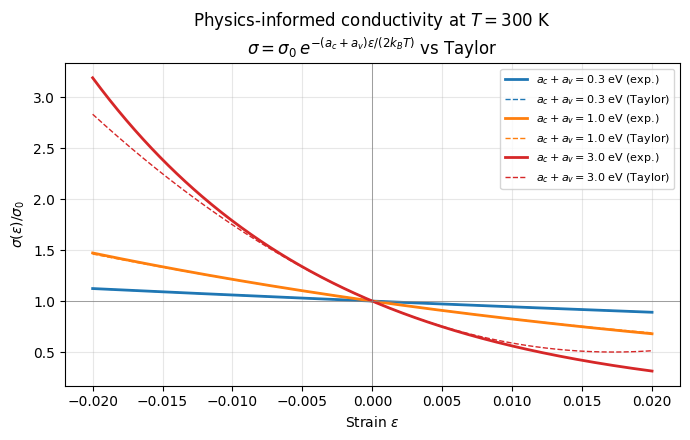

In [43]:
# Figure 1: constitutive law sigma(eps) for the three cases
fig, ax = plt.subplots(figsize=(7, 4.5))
eps_axis = np.linspace(-0.02, 0.02, 400)
colors = ["tab:blue", "tab:orange", "tab:red"]
for r, c in zip(cases, colors):
    s_exp = sigma_exponential(eps_axis, r['sigma0'], r['a_sum_eV'], r['T'])
    s_tay = sigma_from_strain(eps_axis, r['sigma0'], r['pi'], r['alpha'])
    ax.plot(eps_axis, s_exp, color=c, lw=2,
            label=rf"$a_c+a_v={r['a_sum_eV']}$ eV (exp.)")
    ax.plot(eps_axis, s_tay, color=c, lw=1, ls="--",
            label=rf"$a_c+a_v={r['a_sum_eV']}$ eV (Taylor)")
ax.axhline(1.0, color="gray", lw=0.5); ax.axvline(0.0, color="gray", lw=0.5)
ax.set_xlabel(r"Strain $\varepsilon$")
ax.set_ylabel(r"$\sigma(\varepsilon)/\sigma_0$")
ax.set_title(r"Physics-informed conductivity at $T=300$ K"+"\n"+
             r"$\sigma=\sigma_0\,e^{-(a_c+a_v)\varepsilon/(2 k_B T)}$ vs Taylor")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("../paper/Images/fig_sigma_law.png", dpi=200, bbox_inches="tight")
plt.show()


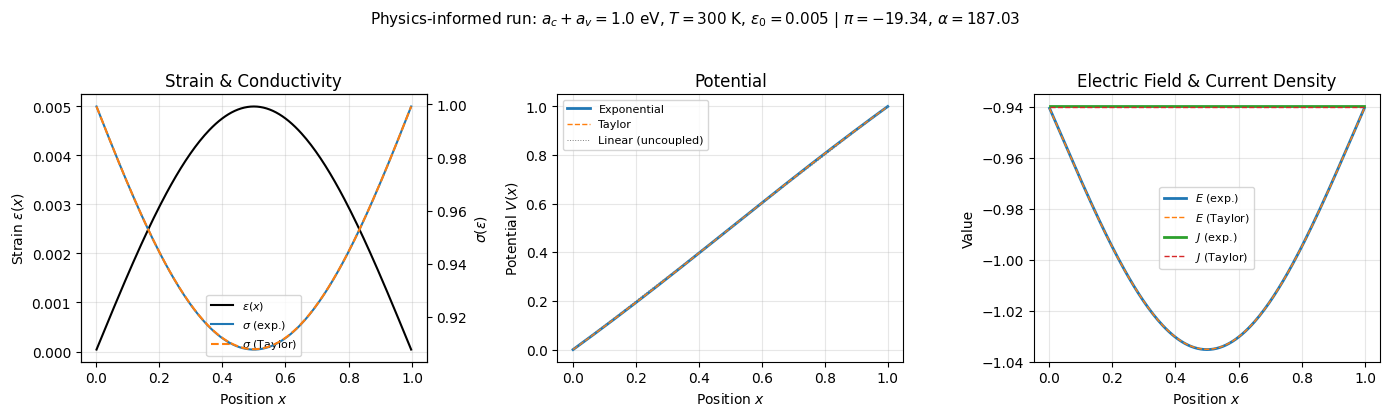

In [44]:
# Figure 2: FEM result for the moderate case (a_c+a_v = 1 eV)
r = cases[1]
fig, axs = plt.subplots(1, 3, figsize=(14, 4.2))

axs[0].plot(r['x_elem'], r['eps'], color="k", label=r"$\varepsilon(x)$")
ax2 = axs[0].twinx()
ax2.plot(r['x_elem'], r['sigma_exp'], color="tab:blue", label=r"$\sigma$ (exp.)")
ax2.plot(r['x_elem'], r['sigma_tay'], color="tab:orange", ls="--", label=r"$\sigma$ (Taylor)")
axs[0].set_xlabel("Position $x$"); axs[0].set_ylabel(r"Strain $\varepsilon(x)$")
ax2.set_ylabel(r"$\sigma(\varepsilon)$"); axs[0].set_title("Strain & Conductivity")
axs[0].grid(True, alpha=0.3)
h1, l1 = axs[0].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axs[0].legend(h1+h2, l1+l2, loc="lower center", fontsize=8)

axs[1].plot(r['x_node'], r['V_exp'], color="tab:blue", lw=2, label="Exponential")
axs[1].plot(r['x_node'], r['V_tay'], color="tab:orange", lw=1, ls="--", label="Taylor")
axs[1].plot(r['x_node'], r['x_node'], color="gray", lw=0.7, ls=":", label="Linear (uncoupled)")
axs[1].set_xlabel("Position $x$"); axs[1].set_ylabel("Potential $V(x)$")
axs[1].set_title("Potential"); axs[1].grid(True, alpha=0.3); axs[1].legend(fontsize=8)

axs[2].plot(r['x_elem'], r['E_exp'], color="tab:blue", lw=2, label="$E$ (exp.)")
axs[2].plot(r['x_elem'], r['E_tay'], color="tab:orange", lw=1, ls="--", label="$E$ (Taylor)")
axs[2].plot(r['x_elem'], r['J_exp'], color="tab:green", lw=2, label="$J$ (exp.)")
axs[2].plot(r['x_elem'], r['J_tay'], color="tab:red", lw=1, ls="--", label="$J$ (Taylor)")
axs[2].set_xlabel("Position $x$"); axs[2].set_ylabel("Value")
axs[2].set_title("Electric Field & Current Density")
axs[2].grid(True, alpha=0.3); axs[2].legend(fontsize=8)

fig.suptitle(rf"Physics-informed run: $a_c+a_v={r['a_sum_eV']}$ eV, "
             rf"$T={r['T']:.0f}$ K, $\varepsilon_0={r['eps0']}$ | "
             rf"$\pi={r['pi']:.2f}$, $\alpha={r['alpha']:.2f}$", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("../paper/Images/fig_FEM_moderate.png", dpi=200, bbox_inches="tight")
plt.show()


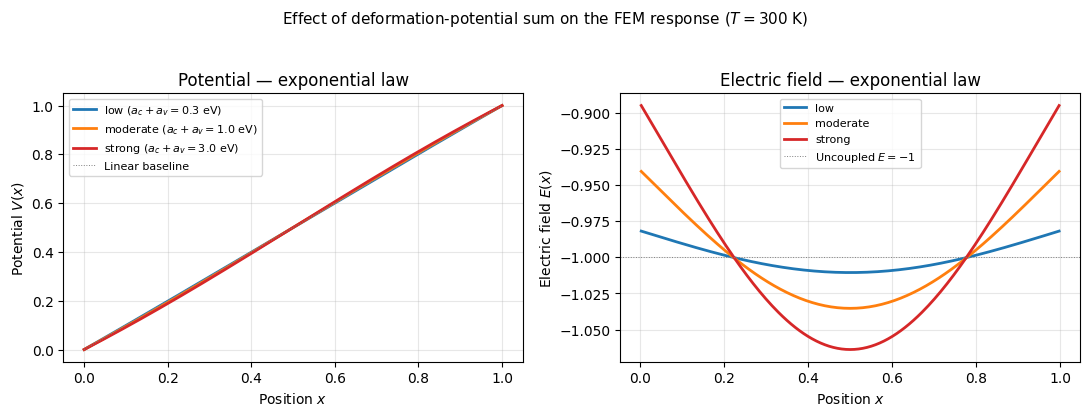

In [45]:
# Figure 3: side-by-side comparison of the three coupling strengths
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
for r, c in zip(cases, ["tab:blue", "tab:orange", "tab:red"]):
    axs[0].plot(r['x_node'], r['V_exp'], color=c, lw=2,
                label=rf"{r['label']} ($a_c+a_v={r['a_sum_eV']}$ eV)")
    axs[1].plot(r['x_elem'], r['E_exp'], color=c, lw=2, label=r['label'])
axs[0].plot(cases[0]['x_node'], cases[0]['x_node'], color="gray", lw=0.7, ls=":",
            label="Linear baseline")
axs[0].set_xlabel("Position $x$"); axs[0].set_ylabel("Potential $V(x)$")
axs[0].set_title("Potential — exponential law")
axs[0].legend(fontsize=8); axs[0].grid(True, alpha=0.3)

axs[1].axhline(-1.0, color="gray", lw=0.7, ls=":", label="Uncoupled $E=-1$")
axs[1].set_xlabel("Position $x$"); axs[1].set_ylabel("Electric field $E(x)$")
axs[1].set_title("Electric field — exponential law")
axs[1].legend(fontsize=8); axs[1].grid(True, alpha=0.3)

fig.suptitle(rf"Effect of deformation-potential sum on the FEM response "
             rf"($T={T:.0f}$ K)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("../paper/Images/fig_compare_cases.png", dpi=200, bbox_inches="tight")
plt.show()


### Discussion

Three observations follow from the runs above:

1. **Coefficient magnitudes.** Even a modest $a_c+a_v \sim 1$ eV at $T=300$ K gives $\pi \approx -19$, comparable to the upper end of the phenomenological range $\pi\in[5,20]$ used earlier. This is a useful sanity check: the deformation-potential prediction is in the right ballpark, with a consistent sign.

2. **Sign of $\pi$.** From $\pi = -(a_c+a_v)/(2 k_B T)$ with positive $a_c+a_v$, $\pi$ is negative: tensile hydrostatic strain ($\varepsilon>0$) widens the gap and *reduces* conductivity. The previous parametric study used positive $\pi$ by convention; the physics fixes the sign.

3. **Exponential vs Taylor.** At the strain amplitudes considered here ($|\varepsilon|\lesssim 5\times 10^{-3}$), the Taylor approximation reproduces the exponential law to within $\sim 10^{-4}$ in $V(x)$, validating the parametric workflow. Deviation grows visibly for large $|a_c+a_v|$ combined with large $|\varepsilon|$ — the regime where the polynomial truncation breaks down.

Current density is conserved to $\sim 10^{-13}$ in all runs, confirming the FEM implementation is sound. The system absorbs spatial variations of $\sigma$ into a non-uniform electric field while keeping $J = \sigma E$ constant, exactly as required by charge conservation in 1D steady state.

**Caveat.** This treatment is the *intrinsic* limit. In doped silicon devices, carrier density is set by ionized dopants and is largely strain-insensitive; the dominant piezoresistive response there comes from strain-induced changes in mobility (effective mass and momentum relaxation time), not from the band-gap shift. A quantitative match with experimental gauge factors in Si would require that mobility channel — left for future work.
